In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

BAG OF VISUAL WORDS AND PCA IMPLEMENTATION

STEP 1: FEATURE EXTRACTION
------------------------------
Total images: 15
Total keypoints extracted: 80
Average keypoints per image: 5.3

STEP 2: VISUAL VOCABULARY CREATION
------------------------------
Running K-means clustering with 10 clusters...
Vocabulary created with 10 visual words
Visual word dimensions: 32

STEP 3: FEATURE QUANTIZATION
------------------------------
Created histograms for 15 images
Histogram shape: (15, 10)

STEP 4: TF-IDF WEIGHTING
------------------------------
TF-IDF vectors computed
TF-IDF shape: (15, 10)

STEP 5: PRINCIPAL COMPONENT ANALYSIS (PCA)
------------------------------
Original dimension: 10
Reduced dimension: 2
Eigenvalues: [0.17728096 0.15555786 0.11317336 0.09612962 0.0645972 ]
Variance explained by PC1: 26.0%
Variance explained by PC2: 22.8%
Total variance explained: 48.9%

STEP 6: VISUALIZATION
------------------------------


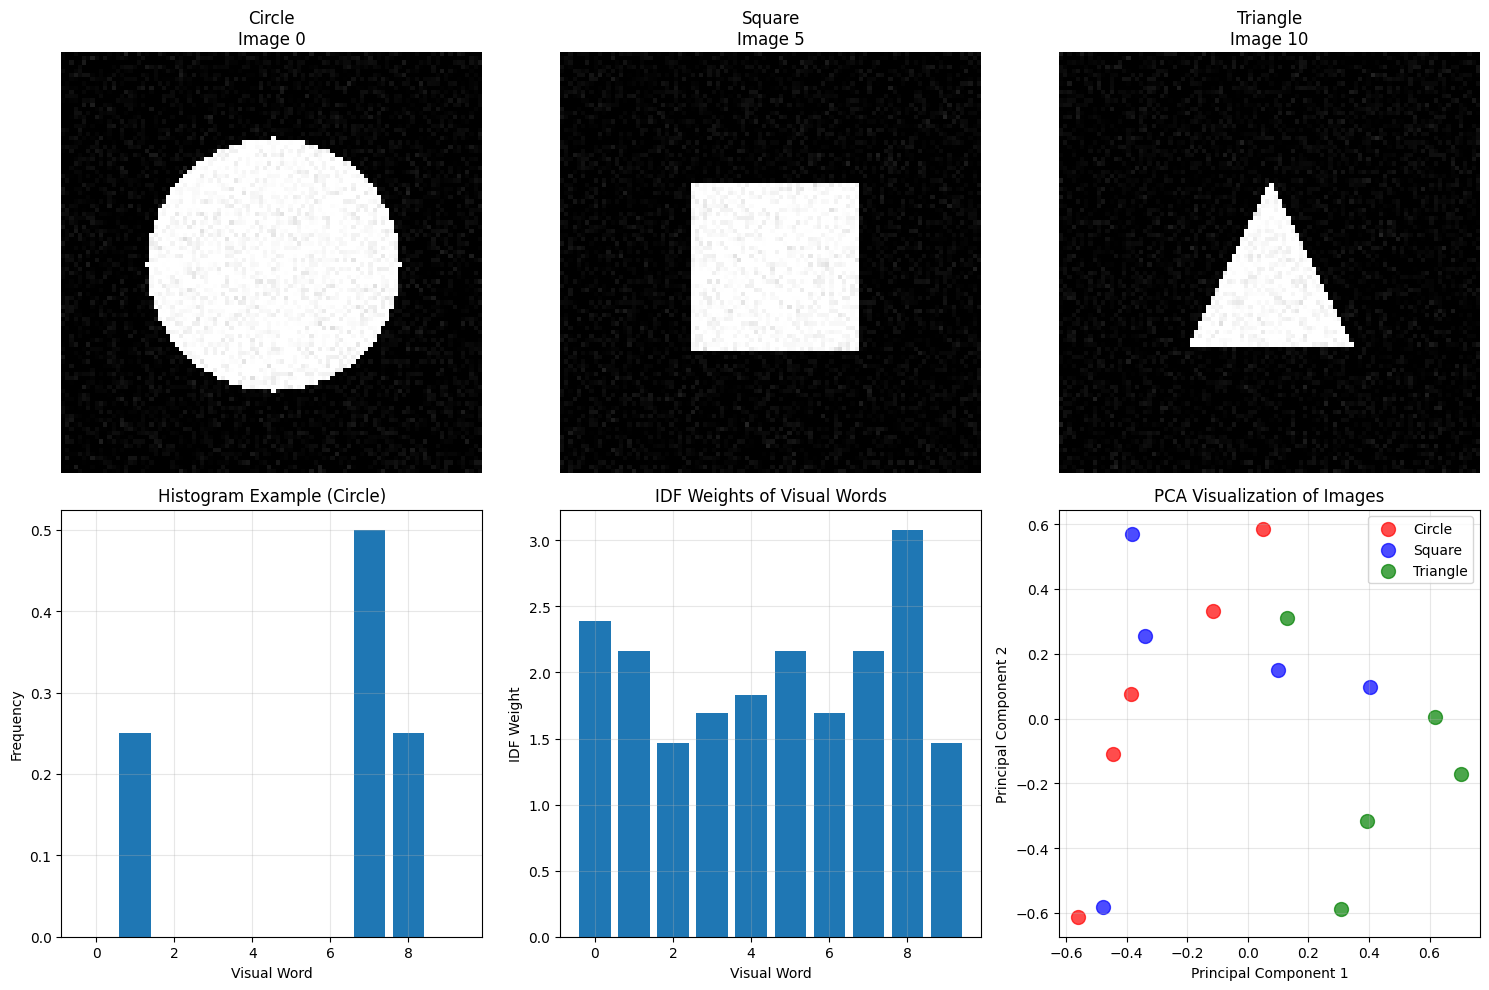


STEP 7: SIMPLE CLASSIFICATION DEMONSTRATION
----------------------------------------
Classification Results:
Image      True Class      Predicted Class      Similarity
------------------------------------------------------------
2          Circle          Circle               0.530     
7          Square          Circle               0.784     
12         Triangle        Square               0.822     

BAG OF VISUAL WORDS PIPELINE SUMMARY:
1. Feature Extraction: ORB descriptors
2. Vocabulary Creation: K-means clustering
3. Vocabulary Size: 10 visual words
4. Feature Quantization: Nearest visual word assignment
5. TF-IDF Weighting: Normalized histogram representation
6. PCA: Dimensionality reduction to 2D
7. Classification: k-NN with cosine similarity
8. Total Images: 15
9. Classes: 3


In [2]:
def latihan_2():
    print("BAG OF VISUAL WORDS AND PCA IMPLEMENTATION")
    print("=" * 50)
    
    # Buat dataset citra sederhana untuk demonstrasi
    def create_simple_dataset():
        images = []
        labels = []
        
        # Class 0: Circles
        for i in range(5):
            img = np.zeros((100, 100), dtype=np.uint8)
            radius = 30 + np.random.randint(-5, 5)
            cv2.circle(img, (50, 50), radius, 255, -1)
            images.append(img)
            labels.append(0)
        
        # Class 1: Squares
        for i in range(5):
            img = np.zeros((100, 100), dtype=np.uint8)
            size = 40 + np.random.randint(-5, 5)
            x = 50 - size//2
            y = 50 - size//2
            cv2.rectangle(img, (x, y), (x+size, y+size), 255, -1)
            images.append(img)
            labels.append(1)
        
        # Class 2: Triangles
        for i in range(5):
            img = np.zeros((100, 100), dtype=np.uint8)
            size = 40 + np.random.randint(-5, 5)
            pts = np.array([[50, 50-size//2], 
                           [50-size//2, 50+size//2], 
                           [50+size//2, 50+size//2]])
            cv2.fillPoly(img, [pts], 255)
            images.append(img)
            labels.append(2)
        
        # Add some noise dan variasi
        for i in range(len(images)):
            noise = np.random.normal(0, 10, images[i].shape)
            images[i] = np.clip(images[i].astype(float) + noise, 0, 255).astype(np.uint8)
        
        return np.array(images), np.array(labels)
    
    images, labels = create_simple_dataset()
    
    # Step 1: Extract features menggunakan ORB (cepat)
    print("\nSTEP 1: FEATURE EXTRACTION")
    print("-" * 30)
    
    orb = cv2.ORB_create(nfeatures=50)
    all_descriptors = []
    all_keypoints = []
    
    for i, img in enumerate(images):
        kp, des = orb.detectAndCompute(img, None)
        if des is not None:
            all_descriptors.extend(des)
            all_keypoints.append((i, len(kp)))
    
    print(f"Total images: {len(images)}")
    print(f"Total keypoints extracted: {len(all_descriptors)}")
    print(f"Average keypoints per image: {len(all_descriptors)/len(images):.1f}")
    
    # Step 2: Create visual vocabulary menggunakan K-means
    print("\nSTEP 2: VISUAL VOCABULARY CREATION")
    print("-" * 30)
    
    # Convert descriptors to float32 untuk kmeans
    all_descriptors = np.array(all_descriptors, dtype=np.float32)
    
    # Define vocabulary size
    vocab_size = 10  # Small vocabulary untuk demonstrasi
    
    # Kriteria untuk kmeans
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)
    
    # Jalankan kmeans
    print(f"Running K-means clustering with {vocab_size} clusters...")
    _, labels_kmeans, centers = cv2.kmeans(all_descriptors, vocab_size, None, 
                                          criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    print(f"Vocabulary created with {vocab_size} visual words")
    print(f"Visual word dimensions: {centers.shape[1]}")
    
    # Step 3: Quantize features untuk setiap citra
    print("\nSTEP 3: FEATURE QUANTIZATION")
    print("-" * 30)
    
    # Buat matcher untuk quantization
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    
    image_histograms = []
    
    for i, img in enumerate(images):
        kp, des = orb.detectAndCompute(img, None)
        
        if des is not None:
            # Quantize setiap descriptor ke visual word terdekat
            histogram = np.zeros(vocab_size)
            
            for d in des:
                # Convert ke float32 untuk matching
                d_float = d.astype(np.float32).reshape(1, -1)
                
                # Hitung distance ke setiap visual word
                distances = np.linalg.norm(centers - d_float, axis=1)
                
                # Temukan visual word terdekat
                closest_word = np.argmin(distances)
                histogram[closest_word] += 1
            
            # Normalisasi histogram
            if np.sum(histogram) > 0:
                histogram = histogram / np.sum(histogram)
            
            image_histograms.append(histogram)
        else:
            image_histograms.append(np.zeros(vocab_size))
    
    image_histograms = np.array(image_histograms)
    
    print(f"Created histograms for {len(image_histograms)} images")
    print(f"Histogram shape: {image_histograms.shape}")
    
    # Step 4: TF-IDF Weighting
    print("\nSTEP 4: TF-IDF WEIGHTING")
    print("-" * 30)
    
    def compute_tfidf(histograms):
        # Term Frequency (already normalized)
        tf = histograms
        
        # Document Frequency
        df = np.sum(histograms > 0, axis=0)
        
        # Inverse Document Frequency
        N = histograms.shape[0]
        idf = np.log((N + 1) / (df + 1)) + 1  # Smoothed IDF
        
        # TF-IDF
        tfidf = tf * idf
        
        # Normalize L2
        norms = np.linalg.norm(tfidf, axis=1, keepdims=True)
        norms[norms == 0] = 1  # Avoid division by zero
        tfidf_normalized = tfidf / norms
        
        return tfidf_normalized, tf, idf
    
    tfidf_vectors, tf, idf = compute_tfidf(image_histograms)
    
    print("TF-IDF vectors computed")
    print(f"TF-IDF shape: {tfidf_vectors.shape}")
    
    # Step 5: PCA untuk dimensionality reduction
    print("\nSTEP 5: PRINCIPAL COMPONENT ANALYSIS (PCA)")
    print("-" * 30)
    
    def manual_pca(data, n_components=2):
        """Implement PCA manually"""
        # 1. Center data
        mean = np.mean(data, axis=0)
        data_centered = data - mean
        
        # 2. Compute covariance matrix
        covariance_matrix = np.cov(data_centered, rowvar=False)
        
        # 3. Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        
        # 4. Sort eigenvalues dan eigenvectors
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # 5. Select top n_components
        components = eigenvectors[:, :n_components]
        
        # 6. Transform data
        transformed = np.dot(data_centered, components)
        
        return transformed, eigenvalues, eigenvectors, mean
    
    # Apply PCA
    pca_result, eigenvalues, eigenvectors, mean = manual_pca(tfidf_vectors, n_components=2)
    
    print(f"Original dimension: {tfidf_vectors.shape[1]}")
    print(f"Reduced dimension: {pca_result.shape[1]}")
    print(f"Eigenvalues: {eigenvalues[:5]}")  # Print top 5 eigenvalues
    
    # Variance explained
    total_variance = np.sum(eigenvalues)
    variance_explained = eigenvalues[:2] / total_variance * 100
    print(f"Variance explained by PC1: {variance_explained[0]:.1f}%")
    print(f"Variance explained by PC2: {variance_explained[1]:.1f}%")
    print(f"Total variance explained: {np.sum(variance_explained):.1f}%")
    
    # Step 6: Visualisasi hasil
    print("\nSTEP 6: VISUALIZATION")
    print("-" * 30)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot 1: Sample images
    sample_indices = [0, 5, 10]  # Satu dari setiap kelas
    for idx, sample_idx in enumerate(sample_indices):
        axes[0, idx].imshow(images[sample_idx], cmap='gray')
        class_name = ['Circle', 'Square', 'Triangle'][labels[sample_idx]]
        axes[0, idx].set_title(f'{class_name}\nImage {sample_idx}')
        axes[0, idx].axis('off')
    
    # Plot 2: Visual vocabulary (centers as images)
    axes[0, 2].axis('off')  # Kosongkan plot
    
    # Plot 3: Histogram contoh
    axes[1, 0].bar(range(vocab_size), image_histograms[0])
    axes[1, 0].set_title('Histogram Example (Circle)')
    axes[1, 0].set_xlabel('Visual Word')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: TF-IDF weights untuk visual words
    axes[1, 1].bar(range(vocab_size), idf)
    axes[1, 1].set_title('IDF Weights of Visual Words')
    axes[1, 1].set_xlabel('Visual Word')
    axes[1, 1].set_ylabel('IDF Weight')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 5: PCA visualization
    colors = ['red', 'blue', 'green']
    for class_idx in range(3):
        class_mask = labels == class_idx
        axes[1, 2].scatter(pca_result[class_mask, 0], pca_result[class_mask, 1], 
                          c=colors[class_idx], label=['Circle', 'Square', 'Triangle'][class_idx],
                          alpha=0.7, s=100)
    
    axes[1, 2].set_title('PCA Visualization of Images')
    axes[1, 2].set_xlabel('Principal Component 1')
    axes[1, 2].set_ylabel('Principal Component 2')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Step 7: Image classification sederhana menggunakan BoVW + PCA
    print("\nSTEP 7: SIMPLE CLASSIFICATION DEMONSTRATION")
    print("-" * 40)
    
    def classify_image_knn(query_hist, training_hists, training_labels, k=3):
        """Simple k-NN classifier menggunakan histogram"""
        # Hitung cosine similarity
        similarities = []
        for train_hist in training_hists:
            # Cosine similarity
            similarity = np.dot(query_hist, train_hist) / (
                np.linalg.norm(query_hist) * np.linalg.norm(train_hist) + 1e-8)
            similarities.append(similarity)
        
        similarities = np.array(similarities)
        
        # Ambil k nearest neighbors
        nearest_indices = np.argsort(similarities)[::-1][:k]
        nearest_labels = training_labels[nearest_indices]
        
        # Majority voting
        from collections import Counter
        most_common = Counter(nearest_labels).most_common(1)
        
        return most_common[0][0], similarities[nearest_indices]
    
    # Test dengan beberapa citra
    test_indices = [2, 7, 12]  # Test images
    print("Classification Results:")
    print(f"{'Image':<10} {'True Class':<15} {'Predicted Class':<20} {'Similarity':<10}")
    print("-" * 60)
    
    for test_idx in test_indices:
        # Pisahkan training dan test
        train_mask = np.ones(len(images), dtype=bool)
        train_mask[test_idx] = False
        
        # Train dan test data
        train_hists = tfidf_vectors[train_mask]
        train_labels = labels[train_mask]
        test_hist = tfidf_vectors[test_idx]
        true_label = labels[test_idx]
        
        # Classify
        pred_label, similarities = classify_image_knn(test_hist, train_hists, train_labels, k=3)
        
        true_class = ['Circle', 'Square', 'Triangle'][true_label]
        pred_class = ['Circle', 'Square', 'Triangle'][pred_label]
        
        print(f"{test_idx:<10} {true_class:<15} {pred_class:<20} {np.mean(similarities):<10.3f}")
    
    # Summary
    print("\nBAG OF VISUAL WORDS PIPELINE SUMMARY:")
    print("=" * 50)
    print("1. Feature Extraction: ORB descriptors")
    print("2. Vocabulary Creation: K-means clustering")
    print(f"3. Vocabulary Size: {vocab_size} visual words")
    print("4. Feature Quantization: Nearest visual word assignment")
    print("5. TF-IDF Weighting: Normalized histogram representation")
    print("6. PCA: Dimensionality reduction to 2D")
    print(f"7. Classification: k-NN with cosine similarity")
    print(f"8. Total Images: {len(images)}")
    print(f"9. Classes: {len(np.unique(labels))}")
    
    return {
        'images': images,
        'labels': labels,
        'histograms': image_histograms,
        'tfidf': tfidf_vectors,
        'pca_result': pca_result,
        'vocab_size': vocab_size
    }

# Jalankan latihan 2
bovw_results = latihan_2()